# EDA - Fair Price Finder
**Dataset:** `merged_raw_imputed.csv` (hasil imputation dari Fastwork, Sribu, Projects.co.id)

In [31]:
from pathlib import Path
import pandas as pd
import numpy as np


def find_project_root():
    current_dir = Path.cwd().resolve()
    for candidate in [current_dir, *current_dir.parents]:
        if (candidate / "data").exists():
            return candidate
    return current_dir


PROJECT_ROOT = find_project_root()
DATA_PATH = PROJECT_ROOT / "data" / "raw" / "data" / "cleaned" / "merged_raw_imputed.csv"

df = pd.read_csv(DATA_PATH)
print(f'Shape: {df.shape}')
print(f'Jumlah kolom: {df.shape[1]}')
print(f'Jumlah baris: {df.shape[0]}')

Shape: (5461, 10)
Jumlah kolom: 10
Jumlah baris: 5461


---
## 1. Overview Dataset

In [32]:
print('=== Info ===')
df.info()
print()
print('=== Missing Values ===')
missing = df.isnull().sum()
print(missing[missing > 0] if missing.any() else 'Tidak ada missing values')

=== Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5461 entries, 0 to 5460
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   platform        5461 non-null   object 
 1   kategori_utama  5461 non-null   object 
 2   sub_kategori    5461 non-null   object 
 3   judul_listing   5461 non-null   object 
 4   harga           5461 non-null   float64
 5   rating          5461 non-null   float64
 6   jumlah_order    5461 non-null   int64  
 7   durasi_hari     5461 non-null   int64  
 8   skills          5461 non-null   object 
 9   url_listing     5461 non-null   object 
dtypes: float64(2), int64(2), object(6)
memory usage: 426.8+ KB

=== Missing Values ===
Tidak ada missing values


In [33]:
# Cek duplikat
print('=== Duplicate Check ===')
dup = df.duplicated().sum()
print(f'Jumlah baris duplikat: {dup} ({dup/len(df)*100:.2f}%)')

# Duplikat berdasarkan url_listing (lebih akurat)
dup_url = df.duplicated(subset=['url_listing']).sum()
print(f'Duplikat berdasarkan url_listing: {dup_url}')

# Duplikat berdasarkan judul + platform + harga
dup_content = df.duplicated(subset=['judul_listing','platform','harga']).sum()
print(f'Duplikat berdasarkan judul + platform + harga: {dup_content}')

if dup > 0:
    print('\nSample duplikat:')
    print(df[df.duplicated(keep=False)][['platform','judul_listing','harga']].head(5))

=== Duplicate Check ===
Jumlah baris duplikat: 357 (6.54%)
Duplikat berdasarkan url_listing: 360
Duplikat berdasarkan judul + platform + harga: 440

Sample duplikat:
     platform                                      judul_listing     harga
600  fastwork  JASA DATA SCIENCE | AI, MECHINE LEARNING, DEEP...  300000.0
602  fastwork               ANALISIS SENTIMEN/ANALYSIS SENTIMENT  300000.0
603  fastwork  Jasa Analisis Sentimen AI – Twitter, Instagram...  300000.0
604  fastwork            Visualization FlexDaashboard Interaktif  300000.0
605  fastwork                            Convert & Excel Support  300000.0


In [34]:
df[['harga', 'rating', 'jumlah_order', 'durasi_hari']].describe().round(2)

,harga,rating,jumlah_order,durasi_hari
count,5461.00,5461.00,5461.00,5461.00
mean,691456.75,2.87,21.91,43.98
std,1720848.90,2.43,684.59,614.58
min,40000.00,0.00,0.00,0.00
25%,150000.00,0.00,0.00,1.00
50%,300000.00,4.90,1.00,2.00
75%,650000.00,5.00,4.00,5.00
max,50000000.00,5.00,50447.00,9786.00


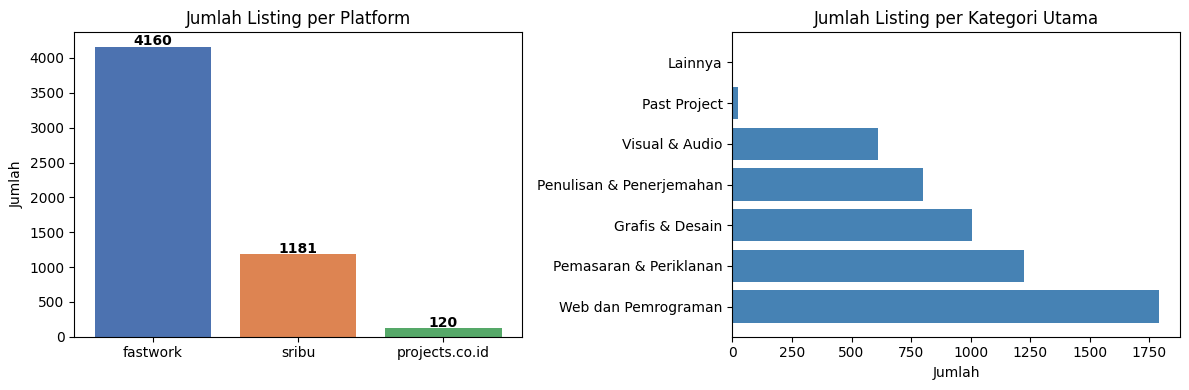

In [35]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
# Distribusi per platform
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

platform_counts = df['platform'].value_counts()
axes[0].bar(platform_counts.index, platform_counts.values, color=['#4C72B0','#DD8452','#55A868'])
axes[0].set_title('Jumlah Listing per Platform')
axes[0].set_ylabel('Jumlah')
for i, v in enumerate(platform_counts.values):
    axes[0].text(i, v + 20, str(v), ha='center', fontweight='bold')

kategori_counts = df['kategori_utama'].value_counts()
axes[1].barh(kategori_counts.index, kategori_counts.values, color='steelblue')
axes[1].set_title('Jumlah Listing per Kategori Utama')
axes[1].set_xlabel('Jumlah')

plt.tight_layout()
plt.show()

---
## 2. Distribusi Harga

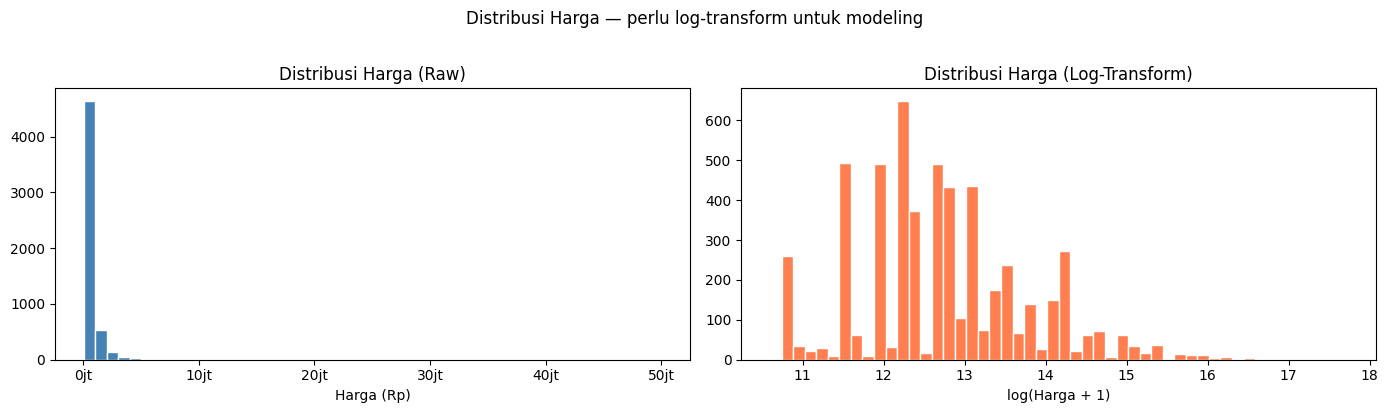

Skewness harga asli  : 14.36
Skewness log(harga)  : 0.59


In [36]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Distribusi harga asli
axes[0].hist(df['harga'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Distribusi Harga (Raw)')
axes[0].set_xlabel('Harga (Rp)')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.0f}jt'))

# Log-transform
axes[1].hist(np.log1p(df['harga']), bins=50, color='coral', edgecolor='white')
axes[1].set_title('Distribusi Harga (Log-Transform)')
axes[1].set_xlabel('log(Harga + 1)')

plt.suptitle('Distribusi Harga — perlu log-transform untuk modeling', y=1.02)
plt.tight_layout()
plt.show()

print(f"Skewness harga asli  : {df['harga'].skew():.2f}")
print(f"Skewness log(harga)  : {np.log1p(df['harga']).skew():.2f}")

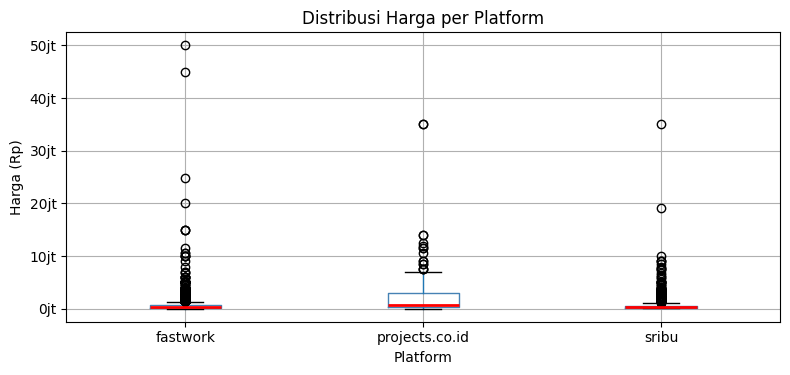

C:\Users\ASUS\AppData\Local\Temp\ipykernel_19600\3269855487.py:14: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df.groupby('platform')['harga'].agg(['min','median','mean','max']).applymap(lambda x: f'Rp {x:,.0f}')


,min,median,mean,max
platform,,,,
fastwork,"Rp 40,000","Rp 300,000","Rp 619,689","Rp 50,000,000"
projects.co.id,"Rp 50,000","Rp 800,000","Rp 2,972,267","Rp 35,000,000"
sribu,"Rp 99,000","Rp 250,000","Rp 712,505","Rp 35,000,000"


In [37]:
# Harga per platform
fig, ax = plt.subplots(figsize=(8, 4))
df.boxplot(column='harga', by='platform', ax=ax, 
           boxprops=dict(color='steelblue'),
           medianprops=dict(color='red', linewidth=2))
ax.set_title('Distribusi Harga per Platform')
ax.set_xlabel('Platform')
ax.set_ylabel('Harga (Rp)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.0f}jt'))
plt.suptitle('')
plt.tight_layout()
plt.show()

df.groupby('platform')['harga'].agg(['min','median','mean','max']).applymap(lambda x: f'Rp {x:,.0f}')

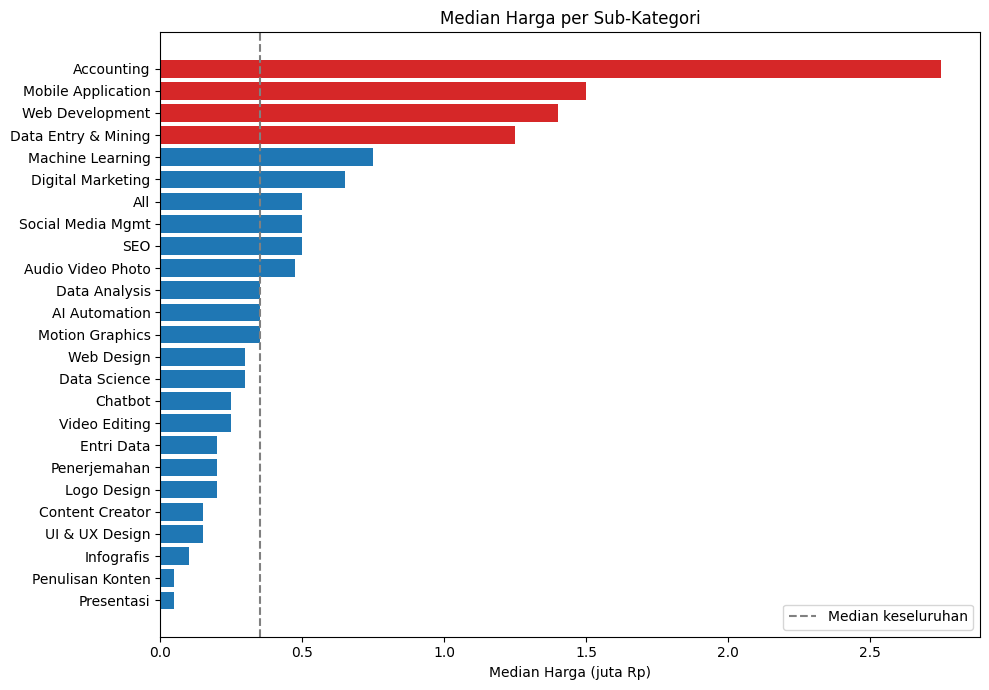

In [38]:
# Median harga per sub_kategori
median_harga = df.groupby('sub_kategori')['harga'].median().sort_values()
# Filter sub_kategori yang punya minimal 10 data
valid_subkat = df['sub_kategori'].value_counts()
valid_subkat = valid_subkat[valid_subkat >= 10].index
median_harga = median_harga[median_harga.index.isin(valid_subkat)]

fig, ax = plt.subplots(figsize=(10, 7))
colors = ['#d62728' if v > 1_000_000 else '#1f77b4' for v in median_harga.values]
ax.barh(median_harga.index, median_harga.values / 1e6, color=colors)
ax.set_xlabel('Median Harga (juta Rp)')
ax.set_title('Median Harga per Sub-Kategori')
ax.axvline(x=median_harga.median()/1e6, color='gray', linestyle='--', label='Median keseluruhan')
ax.legend()
plt.tight_layout()
plt.show()

---
## 3. Rating & Jumlah Order

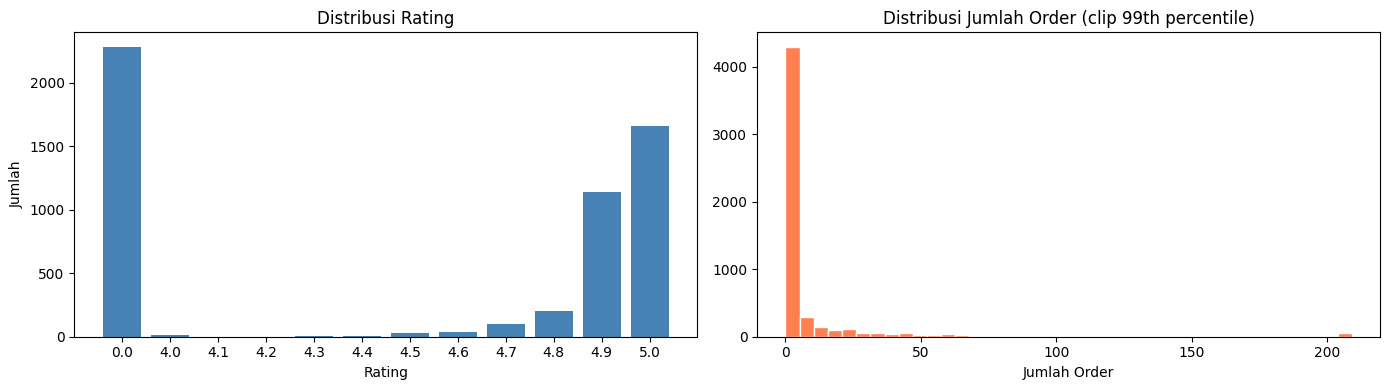

Seller dengan rating 0 (baru): 2284 (41.8%)
Seller dengan 0 order        : 2522 (46.2%)


In [39]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Rating
rating_counts = df['rating'].value_counts().sort_index()
axes[0].bar(rating_counts.index.astype(str), rating_counts.values, color='steelblue')
axes[0].set_title('Distribusi Rating')
axes[0].set_xlabel('Rating')
axes[0].set_ylabel('Jumlah')

# Jumlah order (exclude outlier ekstrem)
order_clip = df['jumlah_order'].clip(upper=df['jumlah_order'].quantile(0.99))
axes[1].hist(order_clip, bins=40, color='coral', edgecolor='white')
axes[1].set_title('Distribusi Jumlah Order (clip 99th percentile)')
axes[1].set_xlabel('Jumlah Order')

plt.tight_layout()
plt.show()

print(f"Seller dengan rating 0 (baru): {(df['rating']==0).sum()} ({(df['rating']==0).mean()*100:.1f}%)")
print(f"Seller dengan 0 order        : {(df['jumlah_order']==0).sum()} ({(df['jumlah_order']==0).mean()*100:.1f}%)")

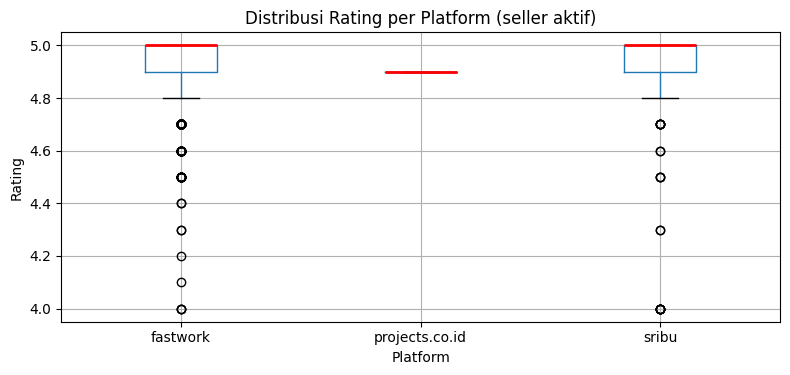

,count,mean,std,min,25%,50%,75%,max
platform,,,,,,,,
fastwork,1905.0,4.923,0.118,4.0,4.9,5.0,5.0,5.0
projects.co.id,120.0,4.900,0.000,4.9,4.9,4.9,4.9,4.9
sribu,1152.0,4.941,0.100,4.0,4.9,5.0,5.0,5.0


In [40]:
# Rating per platform
df_rated = df[df['rating'] > 0]  # exclude seller baru

fig, ax = plt.subplots(figsize=(8, 4))
df_rated.boxplot(column='rating', by='platform', ax=ax,
                 medianprops=dict(color='red', linewidth=2))
ax.set_title('Distribusi Rating per Platform (seller aktif)')
ax.set_xlabel('Platform')
ax.set_ylabel('Rating')
plt.suptitle('')
plt.tight_layout()
plt.show()

df_rated.groupby('platform')['rating'].describe().round(3)

---
## 4. Durasi Pengerjaan

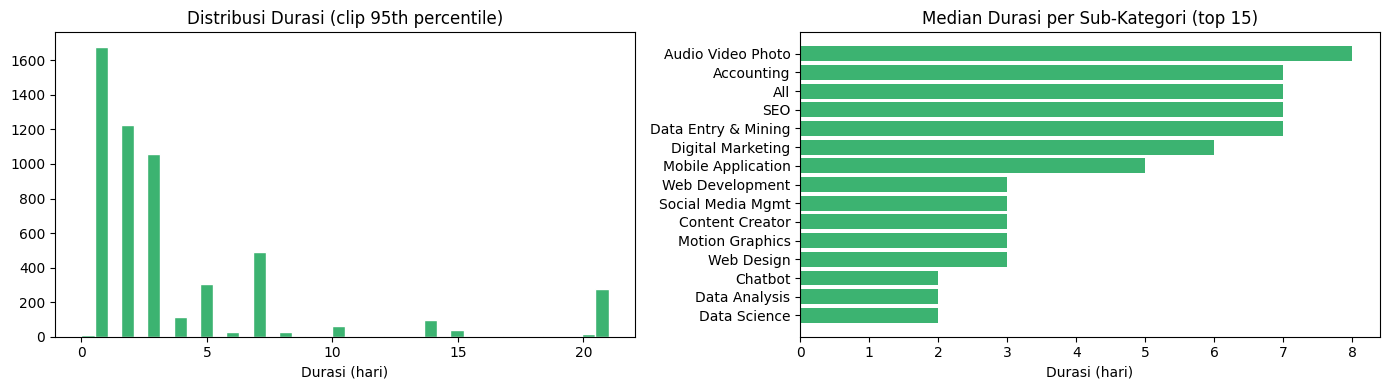

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Clip outlier
durasi_clip = df['durasi_hari'].clip(upper=df['durasi_hari'].quantile(0.95))
axes[0].hist(durasi_clip, bins=40, color='mediumseagreen', edgecolor='white')
axes[0].set_title('Distribusi Durasi (clip 95th percentile)')
axes[0].set_xlabel('Durasi (hari)')

# Median durasi per sub_kategori (top 15)
median_durasi = df.groupby('sub_kategori')['durasi_hari'].median()
median_durasi = median_durasi[median_durasi.index.isin(valid_subkat)].sort_values().tail(15)
axes[1].barh(median_durasi.index, median_durasi.values, color='mediumseagreen')
axes[1].set_title('Median Durasi per Sub-Kategori (top 15)')
axes[1].set_xlabel('Durasi (hari)')

plt.tight_layout()
plt.show()

---
## 5. Korelasi Antar Fitur Numerik

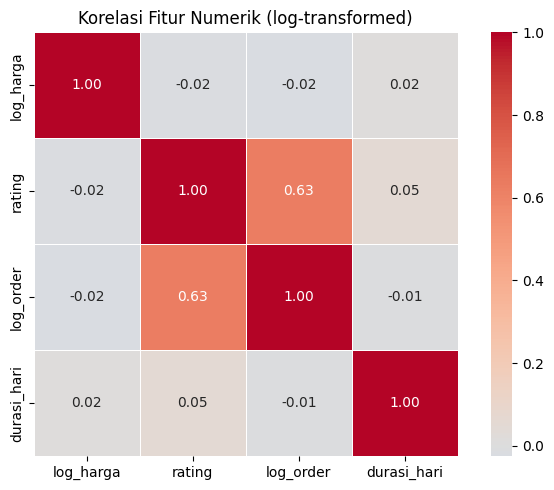

In [42]:
import seaborn as sns
# Pakai log(harga) supaya korelasi lebih meaningful
df_corr = df[['harga', 'rating', 'jumlah_order', 'durasi_hari']].copy()
df_corr['log_harga'] = np.log1p(df['harga'])
df_corr['log_order'] = np.log1p(df['jumlah_order'])

corr_cols = ['log_harga', 'rating', 'log_order', 'durasi_hari']
corr_matrix = df_corr[corr_cols].corr()

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, ax=ax, square=True, linewidths=0.5)
ax.set_title('Korelasi Fitur Numerik (log-transformed)')
plt.tight_layout()
plt.show()

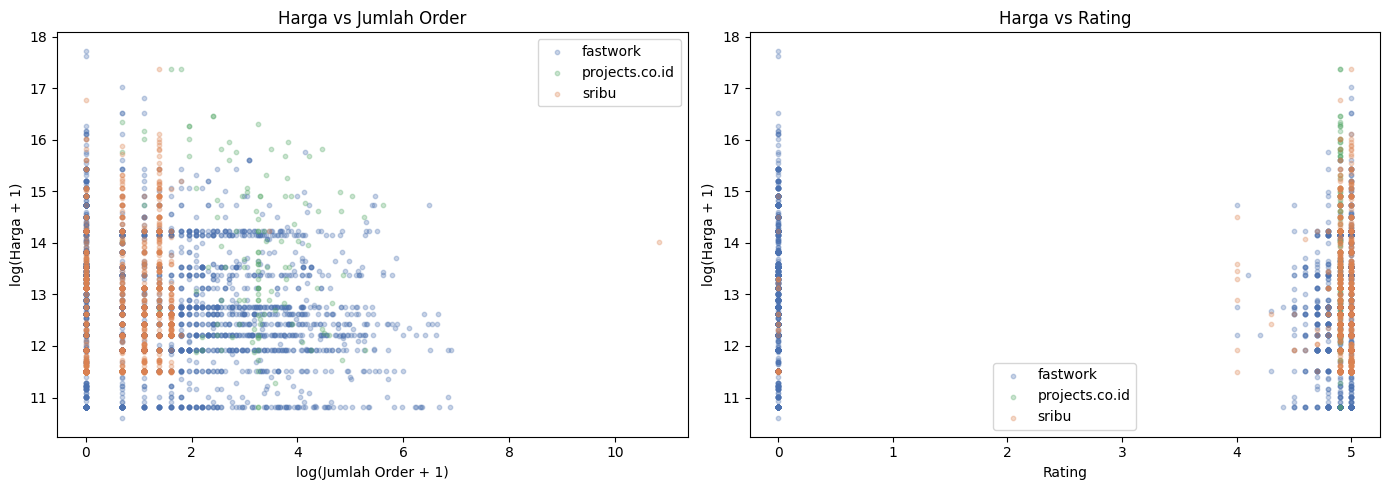

In [43]:
# Scatter: log_harga vs log_order, colored by platform
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors_platform = {'fastwork': '#4C72B0', 'sribu': '#DD8452', 'projects.co.id': '#55A868'}
for platform, grp in df_corr.join(df['platform']).groupby('platform'):
    axes[0].scatter(grp['log_order'], grp['log_harga'],
                   alpha=0.3, s=10, label=platform,
                   color=colors_platform.get(platform, 'gray'))
axes[0].set_xlabel('log(Jumlah Order + 1)')
axes[0].set_ylabel('log(Harga + 1)')
axes[0].set_title('Harga vs Jumlah Order')
axes[0].legend()

for platform, grp in df_corr.join(df['platform']).groupby('platform'):
    axes[1].scatter(grp['rating'], grp['log_harga'],
                   alpha=0.3, s=10, label=platform,
                   color=colors_platform.get(platform, 'gray'))
axes[1].set_xlabel('Rating')
axes[1].set_ylabel('log(Harga + 1)')
axes[1].set_title('Harga vs Rating')
axes[1].legend()

plt.tight_layout()
plt.show()

---
## 6. Outlier Detection

In [44]:
def detect_outliers_iqr(series, label):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_out = ((series < lower) | (series > upper)).sum()
    print(f'{label:20s} → lower: {lower:>12,.0f} | upper: {upper:>12,.0f} | outlier: {n_out} ({n_out/len(series)*100:.1f}%)')
    return lower, upper

print('=== IQR Outlier Detection ===')
h_lo, h_hi = detect_outliers_iqr(df['harga'], 'harga')
o_lo, o_hi = detect_outliers_iqr(df['jumlah_order'], 'jumlah_order')
d_lo, d_hi = detect_outliers_iqr(df['durasi_hari'], 'durasi_hari')

print()
print('Sample outlier harga ekstrem (> Rp 10jt):')
df[df['harga'] > 10_000_000][['platform','sub_kategori','judul_listing','harga']].head(5)

=== IQR Outlier Detection ===
harga                → lower:     -600,000 | upper:    1,400,000 | outlier: 645 (11.8%)
jumlah_order         → lower:           -6 | upper:           10 | outlier: 877 (16.1%)
durasi_hari          → lower:           -5 | upper:           11 | outlier: 451 (8.3%)

Sample outlier harga ekstrem (> Rp 10jt):


,platform,sub_kategori,judul_listing,harga
231,fastwork,Mobile Application,Pembuatan Aplikasi Android & iOS Flutter,15000000.0
263,fastwork,Mobile Application,Jasa Pembuatan Aplikasi Mobile(Android/IOS)/We...,20000000.0
344,fastwork,Mobile Application,Aplikasi Absensi Berbasis Face Recognition,15000000.0
660,fastwork,Data Science,Implementasi ETL,50000000.0
1211,fastwork,Chatbot,Bot berbasis AI custom boleh request,10500000.0


---
## 7. Analisis Skills

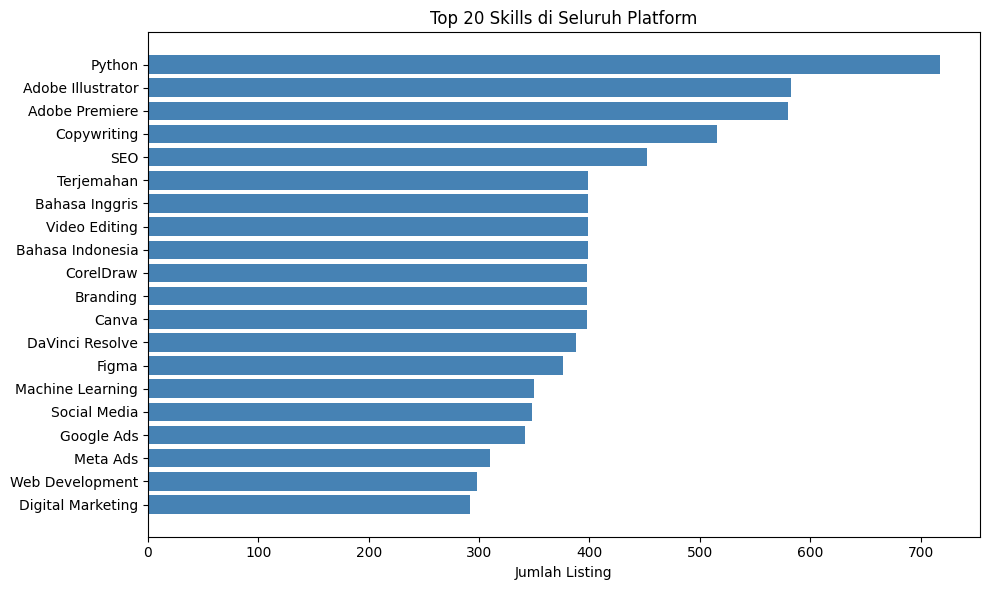

In [45]:
from collections import Counter

# Flatten semua skills
all_skills = []
for s in df['skills'].dropna():
    all_skills.extend([x.strip() for x in str(s).split(',')])

skill_counts = Counter(all_skills)
top_skills = pd.Series(skill_counts).sort_values(ascending=False).head(20)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(top_skills.index[::-1], top_skills.values[::-1], color='steelblue')
ax.set_title('Top 20 Skills di Seluruh Platform')
ax.set_xlabel('Jumlah Listing')
plt.tight_layout()
plt.show()

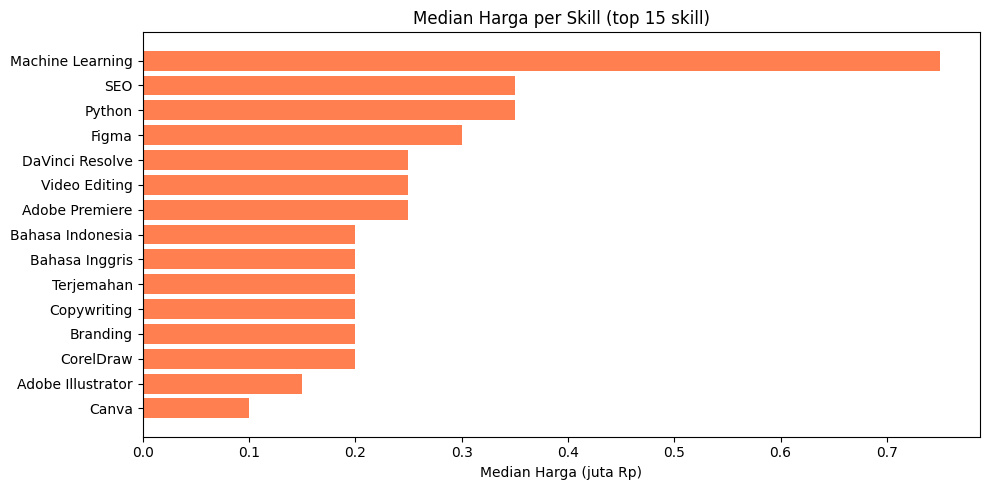

In [46]:
# Median harga per skill (top 15 skill)
top15_skills = [s for s, _ in skill_counts.most_common(15)]

skill_harga = {}
for skill in top15_skills:
    mask = df['skills'].str.contains(skill, na=False)
    skill_harga[skill] = df.loc[mask, 'harga'].median()

skill_harga_s = pd.Series(skill_harga).sort_values()

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(skill_harga_s.index, skill_harga_s.values / 1e6, color='coral')
ax.set_title('Median Harga per Skill (top 15 skill)')
ax.set_xlabel('Median Harga (juta Rp)')
plt.tight_layout()
plt.show()

---
## 8. Ringkasan Insight untuk Modeling

In [47]:
print('=== INSIGHT UNTUK FEATURE ENGINEERING & MODELING ===')
print()
print('1. TARGET VARIABLE')
print('   - Harga sangat right-skewed → gunakan log-transform sebelum training')
print(f"   - Range: Rp {df['harga'].min():,.0f} – Rp {df['harga'].max():,.0f}")
print(f"   - Median: Rp {df['harga'].median():,.0f}")
print()
print('2. FITUR KUNCI')
print('   - sub_kategori: paling kuat menentukan rentang harga')
print('   - platform: projects.co.id rata-rata 2-3x lebih mahal dari fastwork/sribu')
print('   - durasi_hari: berkorelasi positif dengan harga')
print('   - skills: perlu one-hot / multi-label encoding')
print()
print('3. OUTLIER')
print(f"   - Harga > Rp 10jt: {(df['harga'] > 10_000_000).sum()} baris — pertimbangkan di-clip atau dilog")
print(f"   - Durasi > 365 hari: {(df['durasi_hari'] > 365).sum()} baris — kemungkinan data entry error")
print()
print('4. SELLER BARU (rating=0, order=0)')
print(f"   - {(df['rating']==0).sum()} listing ({(df['rating']==0).mean()*100:.1f}%) — perlu flag sebagai fitur tersendiri")
print()
print('5. NEXT STEP')
print('   - Buat kolom `level` (baru/menengah/senior) dari kombinasi rating + order')
print('   - One-hot encode: platform, kategori_utama, sub_kategori')
print('   - Multi-label encode: skills')
print('   - Log-transform: harga (target), jumlah_order, durasi_hari')
print('   - Simpan ke data/final/ untuk Felicia')

=== INSIGHT UNTUK FEATURE ENGINEERING & MODELING ===

1. TARGET VARIABLE
   - Harga sangat right-skewed → gunakan log-transform sebelum training
   - Range: Rp 40,000 – Rp 50,000,000
   - Median: Rp 300,000

2. FITUR KUNCI
   - sub_kategori: paling kuat menentukan rentang harga
   - platform: projects.co.id rata-rata 2-3x lebih mahal dari fastwork/sribu
   - durasi_hari: berkorelasi positif dengan harga
   - skills: perlu one-hot / multi-label encoding

3. OUTLIER
   - Harga > Rp 10jt: 21 baris — pertimbangkan di-clip atau dilog
   - Durasi > 365 hari: 22 baris — kemungkinan data entry error

4. SELLER BARU (rating=0, order=0)
   - 2284 listing (41.8%) — perlu flag sebagai fitur tersendiri

5. NEXT STEP
   - Buat kolom `level` (baru/menengah/senior) dari kombinasi rating + order
   - One-hot encode: platform, kategori_utama, sub_kategori
   - Multi-label encode: skills
   - Log-transform: harga (target), jumlah_order, durasi_hari
   - Simpan ke data/final/ untuk Felicia
